# DATA PREPARATION

In [29]:
# ------------------------------------------
# INITIATION: PYTHON AND DISPLAY
# ------------------------------------------

# Import libraries
import pandas as pd #
import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt #charts
import seaborn as sns #charts
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro, jarque_bera

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from statsmodels.regression.quantile_regression import QuantReg
import statsmodels.formula.api as smf

import shap

from sklearn.linear_model import LassoCV



# For better visibility
from IPython.display import display, HTML

# Apply a no-wrap style to prevent text wrapping
display(HTML("""
<style>
.dataframe td { white-space: nowrap; }
</style>
"""))

# Set the option to display all columns
pd.set_option('display.max_columns', None)

# Set the option to display all rows
pd.set_option('display.max_rows', None)

# Set the float format to use a space as a thousands separator and a comma as a decimal separator
pd.set_option('display.float_format', lambda x: f'{x:,.2f}'.replace(',', ' ').replace('.', ','))

In [30]:
# ------------------------------------------
# FILE LOAD
# ------------------------------------------

# Read the Excel file into a DataFrame
df = pd.read_excel('2000 Analysis Python CHANGED.xlsx', decimal=',')
display (df.head())

,2023,2022,2021,2020,2019,Name,NIP,PKD,PKD Opis,Sector,Owner Type,Year,Sales,Gross Profit,Operating Profit,Net Profit,Depreciation,Export Sales,Employment,Staff costs,BS,Fixed Assets,Current Assets,Equity,Liabilities,PKD_2,PKD_1,PKD_1 Description,PKD_2 Description,Digital intensity,Export as % of Sales,ROS,ROA,ROE,P/F,BS_Strength,Human_Capital,GVA,Productivity,Hint25,Hint50,HGX,HGX%,SGrowth_2023_2019,LSGrowth_2023_2019,RSGrowth_2023_2019,LRSGrowth_2023_2019,Annualised_Growth,Drop_Sales_2020,Drop_Sales_2023,Drop_Sales_Both,SGrowth_3,SGrowth_2,SGrowth_1,GVAGrowth_2023_2019,EGrowth_2023_2019,LEGrowth_2023_2019,Annualised_EGrowth,Drop_Employment,EGrowth_3,EGrowth_2,PGrowth_2023_2019,Starting_Profit,Starting_INT,Starting_BS_Strength,Starting_Size_ln,Starting_Human_Capital,Starting_GVA,Starting_Prod
0,1,"1,00","1,00","1,00",1,"Orlen SA GK, Płock",7740001454,1920,Wytwarzanie i przetwarzanie produktów rafinacj...,Oil,412,2023,"372 767 000,00","28 056 000,00","30 314 000,00","20 727 000,00","142 000,00","102 589 000,00","66 554,00","11 175 000,00","264 178 000,00","170 795 000,00","93 383 000,00","153 180 000,00","110 998 000,00",19,C,Manufacturing,MANUFACTURE AND PROCESSING OF COKE AND REFINED...,Medium-high,"27,52","0,06","0,08","0,14",P,"0,58","167,91","39 231 000,00","589,46",Exp>25,Exp<50,Decreased Export Intensity,"-0,52","235,21","1,21","142,91","0,89","35,31",Yes,No,No,3.Very High,3.Growing,Growing,"31 067 000,00","197,95","1,09","31,38",No,2.Hiring,Hiring,"223,97","0,04","80,00","0,54","18,53","125,31","8 164 000,00","365,49"
1,2,"2,00","3,00","2,00",2,"Jeronimo Martins Polska SA, Kostrzyn",7791011327,4719,Pozostała sprzedaż detaliczna prowadzona w nie...,Retail,500,2023,"98 022 928,00","4 882 170,96","5 121 150,49","4 127 757,73","1 311 227,50","0,00","79 292,00","5 954 379,19","26 597 526,53","11 978 435,65","14 619 090,88","5 299 163,00","21 298 363,10",47,G,Wholesale and Retail Trade; Repair of Motor Ve...,"RETAIL TRADE, EXCEPT OF MOTOR VEHICLES",Medium-high,"0,00","0,04","0,16","0,78",F,"0,20","75,09","10 836 550,15","136,67",Exp<25,Exp<50,Decreased Export Intensity,"0,00","76,38","0,57","27,81","0,25","15,24",No,No,No,1.Moderate,2.Stable,Growing,"4 394 364,76","16,33","0,15","3,85",No,2.Hiring,Hiring,"42,15","0,04","0,00","0,23","17,83","53,43","6 442 185,39","94,52"
2,3,"3,00","4,00","3,00",4,"PGE Polska Grupa Energetyczna GK SA, Lublin",5260250541,7010,Działalność firm centralnych (head offices) i ...,Energy,145,2023,"95 964 000,00","-3 431 000,00","-4 055 000,00","-4 902 000,00","13 455 000,00","25 000,00","42 552,00","6 287 000,00","113 443 000,00","78 340 000,00","35 103 000,00","47 855 000,00","65 588 000,00",70,M,"Professional, Scientific and Technical Activities",ACTIVITIES OF HEAD OFFICES; MANAGEMENT CONSULT...,High,"0,03","-0,05","-0,04","-0,10",P,"0,42","147,75","2 856 000,00","67,12",Exp<25,Exp<50,Decreased Export Intensity,"-0,00","155,04","0,94","84,81","0,61","26,37",No,No,No,2.High,3.Growing,Growing,"2 373 000,00","1,47","0,01","0,37",Yes,1.Sustaining,Hiring,"55,60","-0,10","0,40","0,56","17,44","111,08","483 000,00","11,52"
3,4,"5,00","11,00","17,00",30,"Totalizator Sportowy sp. z o.o. GK, Warszawa",5250010982,9200,Działalność związana z grami losowymi i zakład...,Services,100,2023,"52 269 058,00","385 142,00","453 419,00","362 474,00","189 397,00","0,00","5 894,00","786 162,00","2 893 324,00","1 099 674,00","1 793 650,00","1 669 328,00","1 223 996,00",92,R,"Arts, Entertainment and Recreation",GAMBLING AND BETTING ACTIVITIES,Medium-high,"0,00","0,01","0,13","0,22",P,"0,58","133,38","1 171 304,00","198,73",Exp<25,Exp<50,Decreased Export Intensity,"0,00","428,35","1,66","282,86","1,34","51,61",No,No,No,3.Very High,3.Growing,Growing,"513 096,67","221,37","1,17","33,89",No,2.Hiring,Hiring,"-160,16","0,03","0,00","0,59","16,11","188,29","658 207,33","358,89"
4,5,"11,00","14,00","13,00",15,"Enea SA GK, Poznań",7770020640,3514,Handel energią elektryczną,Energy,145,2023,"48 183 419,00","955 679,00","-508 049,00"

In [31]:
# ------------------------------------------
# VARIABLE MANAGEMENT TEMPLATE
# ------------------------------------------

# 1. Load your full dataset (already cleaned)
df_master = df

# 🟨 ID & Metadata (for exclusion in all analysis)
id_columns = ['NIP','PKD', 'PKD Opis','PKD_1 Description', 'PKD_2 Description','2019', '2020', '2021', '2022', '2023']

# 🟥 Outcome-derived (Exclude from modeling but use in descriptive)
derived_outcomes = ['Opis','Sales','Gross Profit','Net Profit','Depreciation','Export Sales','Employment','Staff costs',
                    'BS','Fixed Assets','Current Assets','Equity','Liabilities',
                    'Export as % of Sales','ROS','ROA','ROE','BS_Strength','Human_Capital','GVA','Productivity',
                    'Hint25','Hint50','SGrowth_2023_2019', 'RSGrowth_2023_2019',
                    'Annualised_Growth','SGrowth_3','SGrowth_2','SGrowth_1',
                    'EGrowth_2023_2019','Annualised_EGrowth','EGrowth_3','EGrowth_2',
]

# ✅ Modeling variables (filtered dynamically)
all_exclusions = id_columns + derived_outcomes

# 3. Build filtered dataset for modeling
df_model = df_master.copy()
df_model = df_model[df_model["Year"] == 2023]  # Focus on 2023
df_model = df_model.drop(columns=[col for col in all_exclusions if col in df_model.columns])

display(df_model.head())

,Name,Sector,Owner Type,Year,Operating Profit,PKD_2,PKD_1,Digital intensity,P/F,HGX,HGX%,LSGrowth_2023_2019,LRSGrowth_2023_2019,Drop_Sales_2020,Drop_Sales_2023,Drop_Sales_Both,GVAGrowth_2023_2019,LEGrowth_2023_2019,Drop_Employment,PGrowth_2023_2019,Starting_Profit,Starting_INT,Starting_BS_Strength,Starting_Size_ln,Starting_Human_Capital,Starting_GVA,Starting_Prod
0,"Orlen SA GK, Płock",Oil,412,2023,"30 314 000,00",19,C,Medium-high,P,Decreased Export Intensity,"-0,52","1,21","0,89",Yes,No,No,"31 067 000,00","1,09",No,"223,97","0,04","80,00","0,54","18,53","125,31","8 164 000,00","365,49"
1,"Jeronimo Martins Polska SA, Kostrzyn",Retail,500,2023,"5 121 150,49",47,G,Medium-high,F,Decreased Export Intensity,"0,00","0,57","0,25",No,No,No,"4 394 364,76","0,15",No,"42,15","0,04","0,00","0,23","17,83","53,43","6 442 185,39","94,52"
2,"PGE Polska Grupa Energetyczna GK SA, Lublin",Energy,145,2023,"-4 055 000,00",70,M,High,P,Decreased Export Intensity,"-0,00","0,94","0,61",No,No,No,"2 373 000,00","0,01",Yes,"55,60","-0,10","0,40","0,56","17,44","111,08","483 000,00","11,52"
3,"Totalizator Sportowy sp. z o.o. GK, Warszawa",Services,100,2023,"453 419,00",92,R,Medium-high,P,Decreased Export Intensity,"0,00","1,66","1,34",No,No,No,"513 096,67","1,17",No,"-160,16","0,03","0,00","0,59","16,11","188,29","658 207,33","358,89"
4,"Enea SA GK, Poznań",Energy,145,2023,"-508 049,00",35,D,Low,P,Decreased Export Intensity,"0,00","1,12","0,79",No,No,No,"360 494,00","0,05",No,"9,78","0,03","0,00","0,47","16,58","112,03","3 688 149,00","217,00"


In [32]:
# ------------------------------------------
# DATA PREPARATION (with winsor/trim option)
# ------------------------------------------

# STEP 1: FILTER TO YEAR 2023
df_2023 = df_model[df_model['Year'] == 2023]

# STEP 2: DEFINE VARIABLES
target_raw = 'LRSGrowth_2023_2019'
numeric_features = ['Starting_INT', 'Starting_BS_Strength', 'Starting_Size_ln', 'Starting_Profit']
categorical_vars = ['P/F', 'Sector', 'HGX']
interaction_terms = [('P/F_P','Starting_Size_ln')]

# Outlier handling parameters
percentile = 0.025
outlier_method = 'trim'  # Change to 'trim' if you want to remove outliers

# STEP 3: DROP MISSING VALUES (WITH COPY)
all_vars = numeric_features + categorical_vars + [target_raw]
before_drop = df_2023["Name"].tolist()

df_clean = df_2023.dropna(subset=all_vars).copy()
after_drop = df_clean["Name"].tolist()

dropped_companies = set(before_drop) - set(after_drop)
dropped_count = len(dropped_companies)

print(f"\nCompanies dropped due to missing values (Total: {dropped_count}):\n")
print("\n".join(sorted(dropped_companies)))

# ------------------------------------------
# STEP 4: OUTLIER HANDLING (winsor or trim)
# ------------------------------------------

def apply_outlier_handling(df, column, method='winsor', percentile=0.05):
    df = df.copy()
    lower = df[column].quantile(percentile)
    upper = df[column].quantile(1 - percentile)

    if method == 'winsor':
        flag_col = f"{column}_was_winsorized"
        win_col = f"{column}_win"
        df[flag_col] = (df[column] < lower) | (df[column] > upper)
        df[win_col] = np.clip(df[column], lower, upper)
        return df, win_col

    elif method == 'trim':
        df_trimmed = df[(df[column] >= lower) & (df[column] <= upper)].copy()
        return df_trimmed, column

    else:
        raise ValueError("Method must be 'winsor' or 'trim'")

# Apply the selected method
df_clean, target_variable = apply_outlier_handling(df_clean, target_raw, method=outlier_method, percentile=percentile)

# Print diagnostics
print(f"\nOutlier handling method: {outlier_method.upper()} (percentile = {percentile})\n")
print(df_clean[target_variable].describe(percentiles=[percentile, 0.25, 0.5, 0.75, 1 - percentile]))

if outlier_method == 'winsor':
    winsorized_count = df_clean[f"{target_raw}_was_winsorized"].sum()
    print(f"\nTotal number of companies winsorized: {winsorized_count}\n")
else:
    print(f"\nTotal number of companies after trimming: {df_clean.shape[0]}\n")


Companies dropped due to missing values (Total: 11):

Grupa Muszkieterów (Intermarché, Bricomarché), Swadzim
Grupa Strabag w Polsce, Pruszków
Intermeble sp. z o.o. sp.k., Poznań
KPMG sp. z o.o. GK, Warszawa 
Kuehne + Nagel sp. z o.o., Gądki
La Lorraine Polska sp. z o.o., Nowy Dwór Mazowiecki
PSH Lewiatan GK, Włocławek
Pilkington (NSG Group w Polsce), Sandomierz
Polska Żegluga Morska PP GK, Szczecin
PwC sp. z o.o. GK, Warszawa 
ZPUE SA, Włoszczowa

Outlier handling method: TRIM (percentile = 0.025)

count   1 405,00
mean        0,07
std         0,25
min        -0,48
2.5%       -0,39
25%        -0,11
50%         0,05
75%         0,22
97.5%       0,64
max         0,81
Name: LRSGrowth_2023_2019, dtype: float64

Total number of companies after trimming: 1405



# OLS Regression


✅ Available Dummy Variables:
Index(['P/F_P', 'Sector_Chemicals', 'Sector_Construction', 'Sector_Energy',
       'Sector_Food', 'Sector_Healthcare and pharma',
       'Sector_Media, telco and IT', 'Sector_Mining and metallurgy',
       'Sector_Oil', 'Sector_Production', 'Sector_Retail', 'Sector_Services',
       'Sector_Transportation', 'Sector_Wholesale',
       'HGX_Increased Export Intensity'],
      dtype='object')

🔍 Trying to add interaction: P/F_P * Starting_Size_ln
  - P/F_P in X_numeric: False
  - Starting_Size_ln in X_numeric: True
  - P/F_P in X_categorical: True
  - Starting_Size_ln in X_categorical: False
✅ Added to X_categorical: P/F_P_Mult_Starting_Size_ln


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     LRSGrowth_2023_2019   R-squared:                       0.055
Model:                             OLS   Adj. R-squared:                  0.041
Method:                  Least Squares   F-statistic:                     4.007
Date:                 Wed, 11 Jun 2025   Prob (F-statistic):           7.31e-09
Time:                         15:27:49   Log-Likelihood:                -12.078
No. Observations:                 1405   AIC:                             66.16
Df Residuals:                     1384   BIC:                             176.4
Df Model:                           20                                         
Covariance Type:             nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              0.0181      0.021      0.870      0.384      -0.023       0.059
Starting_INT                      -0.0053      0.008     -0.705      0.481      -0.020       0.010
Starting_BS_Strength              -0.0039      0.008     -0.513      0.608      -0.019       0.011
Starting_Size_ln                  -0.0285      0.010     -2.987      0.003      -0.047      -0.010
Starting_Profit                    0.0080      0.007      1.103      0.270      -0.006       0.022
P/F_P                              0.0336      0.014      2.397      0.017       0.006       0.061
Sector_Chemicals                   0.0442      0.043      1.030      0.303      -0.040       0.128
Sector_Construction                0.0177      0.028      0.634      0.526      -0.037       0.072
Sector_Energy                      0.3607      0.066      5.458      0.000       0.231       0.490
Sector_Food                        0.0796      0.027      2.980      0.003       0.027       0.132
Sector_Healthcare and pharma       0.0313      0.035      0.887      0.375      -0.038       0.101
Sector_Media, telco and IT        -0.0069      0.034     -0.206      0.837      -0.073       0.059
Sector_Mining and metallurgy      -0.0316      0.048     -0.663      0.507      -0.125       0.062
Sector_Oil                         0.0344      0.041      0.833      0.405      -0.047       0.116
Sector_Production                 -0.0083      0.024     -0.344      0.731      -0.056       0.039
Sector_Retail                     -0.0026      0.038     -0.067      0.946      -0.078       0.072
Sector_Services                    0.0738      0.035      2.117      0.034       0.005       0.142
Sector_Transportation              0.0072      0.034      0.211      0.833      -0.059       0.074
Sector_Wholesale                   0.0093      0.029      0.317      0.751      -0.048       0.067
HGX_Increased Export Intensity     0.0243      0.014      1.791      0.073      -0.002       0.051
P/F_P_Mult_Starting_Size_ln        0.0191      0.014      1.395      0.163      -0.008       0.046
==============================================================================
Omnibus:                       35.412   Durbin-Watson:                   1.882
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               37.450
Skew:                           0.390   Prob(JB):                     7.38e-09
Kurtosis:                       3.176   Cond. No.                         15.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


🔍 Shapiro-Wilk Test (normality):
  Statistic = 0.9894
  p-value   = 0.0000

📦 Jarque-Bera Test (skew + kurtosis):
  Statistic = 37.4500
  p-value   = 0.0000


,Variable,VIF
0,const,"10,01"
1,Starting_INT,"1,33"
2,Starting_BS_Strength,"1,32"
3,Starting_Size_ln,"2,12"
4,Starting_Profit,"1,24"
5,P/F_P,"1,14"
6,Sector_Chemicals,"1,24"
7,Sector_Construction,"1,77"
8,Sector_Energy,"1,21"
9,Sector_Food,"1,80"


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


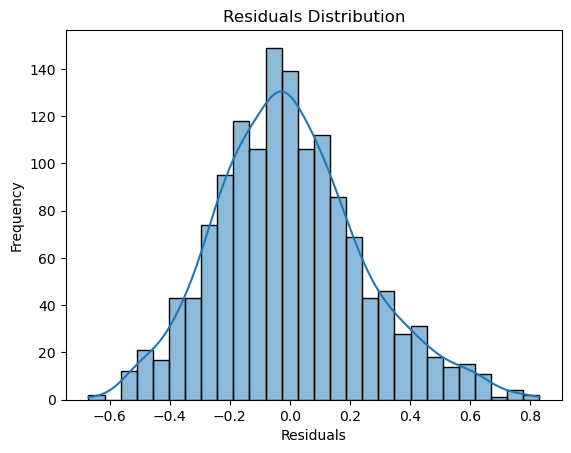

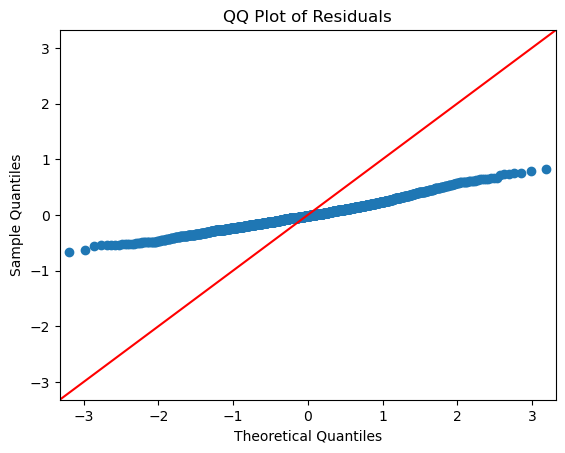

✅ Regression results successfully exported to 'Regression_Results'


In [33]:
# ------------------------------------------
# OLS REGRESSION ANALYSIS
# ------------------------------------------

# STEP 4: ENCODE CATEGORICAL VARIABLES (drop_first to avoid dummy trap)
X_categorical = pd.get_dummies(df_clean[categorical_vars], drop_first=True)

# Print to verify the available dummy columns
print("\n✅ Available Dummy Variables:")
print(X_categorical.columns)

# STEP 5: STANDARDIZE NUMERIC VARIABLES
X_numeric = pd.DataFrame(
    StandardScaler().fit_transform(df_clean[numeric_features]),
    columns=numeric_features,
    index=df_clean.index
)

# STEP 5B: CLEAN COLUMN NAMES TO PREVENT HIDDEN ERRORS
X_numeric.columns = X_numeric.columns.str.strip()
X_categorical.columns = X_categorical.columns.str.strip()

# STEP 5C: DEFINE INTERACTION TERMS
interaction_terms = [(t1.strip(), t2.strip()) for t1, t2 in interaction_terms]

# STEP 5D: ADD INTERACTION TERMS WITH DIAGNOSTICS
for term1, term2 in interaction_terms:
    found_1_num = term1 in X_numeric.columns
    found_2_num = term2 in X_numeric.columns
    found_1_cat = term1 in X_categorical.columns
    found_2_cat = term2 in X_categorical.columns

    print(f"\n🔍 Trying to add interaction: {term1} * {term2}")
    print(f"  - {term1} in X_numeric: {found_1_num}")
    print(f"  - {term2} in X_numeric: {found_2_num}")
    print(f"  - {term1} in X_categorical: {found_1_cat}")
    print(f"  - {term2} in X_categorical: {found_2_cat}")

    # Get the variables
    if found_1_num:
        col1 = X_numeric[term1]
    elif found_1_cat:
        col1 = X_categorical[term1]
    else:
        print(f"⚠️ {term1} not found.")
        continue

    if found_2_num:
        col2 = X_numeric[term2]
    elif found_2_cat:
        col2 = X_categorical[term2]
    else:
        print(f"⚠️ {term2} not found.")
        continue

    # Compute interaction
    interaction_name = f"{term1}_Mult_{term2}"
    interaction_column = col1 * col2

    # Store in correct matrix
    if found_1_num and found_2_num:
        X_numeric[interaction_name] = interaction_column
        print(f"✅ Added to X_numeric: {interaction_name}")
    else:
        X_categorical[interaction_name] = interaction_column
        print(f"✅ Added to X_categorical: {interaction_name}")


# STEP 6: COMBINE FEATURES AND ADD CONSTANT
X_full = pd.concat([X_numeric, X_categorical], axis=1)
X_full = sm.add_constant(X_full).astype(float)

# STEP 7: DEFINE TARGET
y = df_clean[target_variable]

# STEP 8: FIT OLS REGRESSION MODEL
model = sm.OLS(y, X_full).fit()

# Extract coefficients as dataframe
coeff_df = pd.DataFrame({
    "Variable": model.params.index,
    "Coef": model.params.values,
    "Std Err": model.bse.values,
    "t": model.tvalues.values,
    "P>|t|": model.pvalues.values,
    "[0.025": model.conf_int()[0].values,
    "0.975]": model.conf_int()[1].values
})

# Display the full model summary
display(model.summary())

# STEP 8B: EXTRACT REGRESSION SUMMARY STATISTICS
summary_stats = {
    "Statistic": ["R-squared", "Adj. R-squared", "F-statistic", "Prob (F-statistic)", 
                  "Log-Likelihood", "AIC", "BIC", "No. Observations", "DF Residuals", "DF Model"],
    "Value": [
        model.rsquared,
        model.rsquared_adj,
        model.fvalue,
        model.f_pvalue,
        model.llf,
        model.aic,
        model.bic,
        model.nobs,
        model.df_resid,
        model.df_model
    ]
}
summary_df = pd.DataFrame(summary_stats)

# STEP 9: NORMALITY TESTS
residuals = model.resid.replace([np.inf, -np.inf], np.nan).dropna()
shapiro_test = shapiro(residuals)
jb_test = jarque_bera(residuals)

residual_stats = pd.DataFrame({
    "Test": ["Shapiro-Wilk", "Jarque-Bera"],
    "Statistic": [shapiro_test.statistic, jb_test.statistic],
    "p-value": [shapiro_test.pvalue, jb_test.pvalue]
})

print("\n🔍 Shapiro-Wilk Test (normality):")
print(f"  Statistic = {shapiro_test.statistic:.4f}")
print(f"  p-value   = {shapiro_test.pvalue:.4f}")

print("\n📦 Jarque-Bera Test (skew + kurtosis):")
print(f"  Statistic = {jb_test.statistic:.4f}")
print(f"  p-value   = {jb_test.pvalue:.4f}")

# STEP 10: CALCULATE VIF TO CHECK MULTICOLLINEARITY
vif_data = pd.DataFrame({
    "Variable": X_full.columns,
    "VIF": [variance_inflation_factor(X_full.values, i) for i in range(X_full.shape[1])]
})
display(vif_data)

# STEP 11: RESIDUALS DISTRIBUTION PLOT
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# STEP 12: QQ PLOT
sm.qqplot(residuals, line='45')
plt.title("QQ Plot of Residuals")
plt.show()

# STEP 13: COMBINE METADATA + SUMMARY INTO ONE TABLE
from datetime import datetime

now = datetime.now()

# Record outlier method and number of affected observations
if outlier_method == 'winsor':
    outlier_count = int(df_clean[f"{target_raw}_was_winsorized"].sum())
    outlier_description = f"WINSOR (percentile = {percentile})"
    outlier_note = f"{outlier_count} companies winsorized"
else:
    original_n = df_2023.dropna(subset=all_vars).shape[0]
    trimmed_n = df_clean.shape[0]
    outlier_count = original_n - trimmed_n
    outlier_description = f"TRIM (percentile = {percentile})"
    outlier_note = f"{outlier_count} companies trimmed"

# Prepare metadata
metadata_items = [
    ("Dep. Variable", model.model.endog_names),
    ("Model", type(model.model).__name__),
    ("Method", "Least Squares"),
    ("Date", now.strftime("%Y-%m-%d")),
    ("Time", now.strftime("%H:%M:%S")),
    ("No. Observations", model.nobs),
    ("Df Residuals", model.df_resid),
    ("Df Model", model.df_model),
    ("Covariance Type", model.cov_type),
    ("Outlier Handling", outlier_description),
    ("Affected Companies", outlier_note)
]

# Convert summary stats to tuples
summary_items = list(zip(summary_df["Statistic"], summary_df["Value"]))

# Combine both into one list
combined_summary = metadata_items + summary_items

# Create DataFrame
combined_df = pd.DataFrame(combined_summary, columns=["Item", "Value"])

# EXPORT TO EXCEL
with pd.ExcelWriter("Results/Regression_Results.xlsx") as writer:
    combined_df.to_excel(writer, sheet_name="Model_Summary", index=False)
    coeff_df.to_excel(writer, sheet_name="Model_Coefficients", index=False)
    vif_data.to_excel(writer, sheet_name="VIF", index=False)
    residual_stats.to_excel(writer, sheet_name="Residual_Tests", index=False)

print("✅ Regression results successfully exported to 'Regression_Results'")

In [34]:
X_with_dummies = pd.concat([df_clean[categorical_vars], X_categorical], axis=1)
print(X_with_dummies.head(10))

   P/F                 Sector                         HGX  P/F_P  \
1    F                 Retail  Decreased Export Intensity  False   
2    P                 Energy  Decreased Export Intensity   True   
4    P                 Energy  Decreased Export Intensity   True   
5    P                 Energy  Increased Export Intensity   True   
7    F                 Retail  Increased Export Intensity  False   
8    F  Mining and metallurgy  Decreased Export Intensity  False   
9    P  Mining and metallurgy  Decreased Export Intensity   True   
10   P              Wholesale  Decreased Export Intensity   True   
11   P                 Energy  Increased Export Intensity   True   
12   P                 Energy  Decreased Export Intensity   True   

    Sector_Chemicals  Sector_Construction  Sector_Energy  Sector_Food  \
1              False                False          False        False   
2              False                False           True        False   
4              False            

In [22]:
# Exclude "Sector" from the list of categorical variables
categorical_vars_filtered = [var for var in categorical_vars if var != 'Sector']

# Combine numeric and filtered categorical variables
df_combined = pd.get_dummies(
    df_clean[numeric_features + categorical_vars_filtered + [target_variable]],
    drop_first=True
)
# Move the target column to the first position
cols = list(df_combined.columns)
if target_variable in cols:
    cols.insert(0, cols.pop(cols.index(target_variable)))
df_combined = df_combined[cols]

# Calculate the correlation matrix
correlation_matrix = df_combined.corr()

# Reorder the rows as well to place target at the top
correlation_matrix = correlation_matrix.reindex(index=cols, columns=cols)

# Display the correlation matrix
display(correlation_matrix)

# Flatten the correlation matrix and remove self-correlations
correlation_pairs = correlation_matrix.unstack().reset_index()
correlation_pairs.columns = ["Variable 1", "Variable 2", "Correlation"]

# Remove duplicate pairs (A-B and B-A)
correlation_pairs["Pair"] = correlation_pairs.apply(
    lambda row: "-".join(sorted([row["Variable 1"], row["Variable 2"]])), axis=1
)
correlation_pairs.drop_duplicates(subset="Pair", inplace=True)
correlation_pairs.drop(columns=["Pair"], inplace=True)

# Remove self-correlations
correlation_pairs = correlation_pairs[correlation_pairs["Variable 1"] != correlation_pairs["Variable 2"]]

# Sort by absolute correlation value
top_10_correlations = correlation_pairs.reindex(
    correlation_pairs.Correlation.abs().sort_values(ascending=False).index
).head(10)


display(top_10_correlations)

,LRSGrowth_2023_2019_win,Starting_INT,Starting_BS_Strength,Starting_Size_ln,Starting_Profit,P/F_P,HGX_Increased Export Intensity
LRSGrowth_2023_2019_win,"1,00","-0,06","0,01","-0,09","-0,00","0,12","0,03"
Starting_INT,"-0,06","1,00","0,20","0,01","0,09","-0,28","0,06"
Starting_BS_Strength,"0,01","0,20","1,00","-0,06","0,36","-0,07","0,04"
Starting_Size_ln,"-0,09","0,01","-0,06","1,00","-0,08","-0,09","0,01"
Starting_Profit,"-0,00","0,09","0,36","-0,08","1,00","-0,08","0,02"
P/F_P,"0,12","-0,28","-0,07","-0,09","-0,08","1,00","-0,09"
HGX_Increased Export Intensity,"0,03","0,06","0,04","0,01","0,02","-0,09","1,00"


,Variable 1,Variable 2,Correlation
18,Starting_BS_Strength,Starting_Profit,"0,36"
12,Starting_INT,P/F_P,"-0,28"
9,Starting_INT,Starting_BS_Strength,"0,20"
5,LRSGrowth_2023_2019_win,P/F_P,"0,12"
3,LRSGrowth_2023_2019_win,Starting_Size_ln,"-0,09"
26,Starting_Size_ln,P/F_P,"-0,09"
11,Starting_INT,Starting_Profit,"0,09"
41,P/F_P,HGX_Increased Export Intensity,"-0,09"
25,Starting_Size_ln,Starting_Profit,"-0,08"
33,Starting_Profit,P/F_P,"-0,08"


In [23]:
df_clean[['Starting_GVA', 'Starting_Profit']].corr()

,Starting_GVA,Starting_Profit
Starting_GVA,"1,00","0,11"
Starting_Profit,"0,11","1,00"


In [11]:
# TRAINING AND TESTING 
# (checking how well the model generalizes to new data — a key step in any predictive analysis.)

from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error

# STEP A: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.3, random_state=42)

# STEP B: Fit OLS Model on Training Data
model_train = sm.OLS(y_train, X_train).fit()

# STEP C: Make Predictions on Testing Data
y_test_pred = model_train.predict(X_test)

# STEP D: Evaluate Model Performance
test_r2 = r2_score(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Display Test Performance
print(f"Test R² Score: {test_r2:.4f}")
print(f"Test Mean Squared Error: {test_mse:.4f}")


Test R² Score: 0.0703
Test Mean Squared Error: 0.0644


 # Random Forest Feature and Permutations Importance (restricted to OLS)

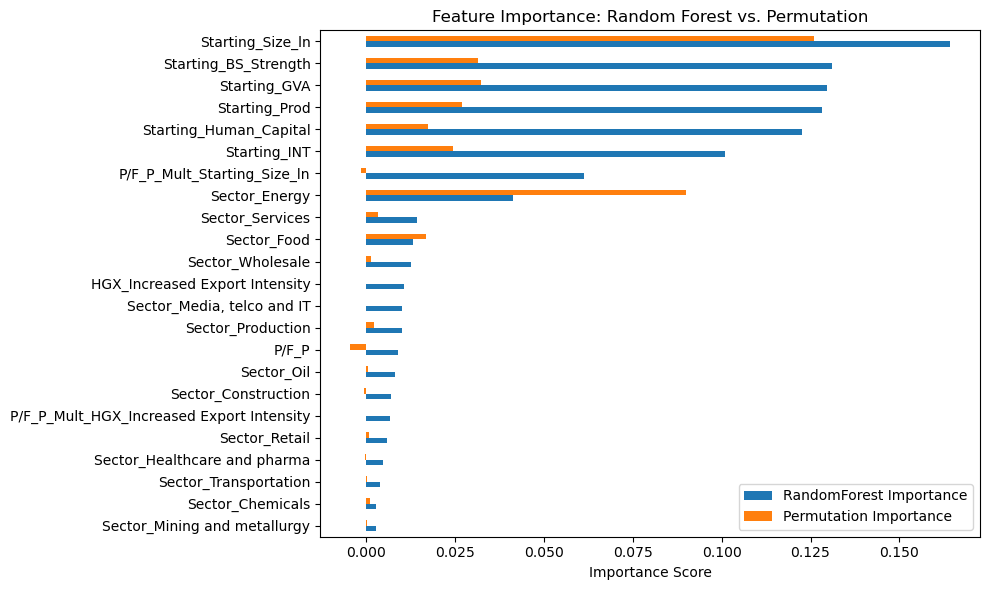

,RandomForest Importance,Permutation Importance
Starting_Size_ln,"0,16","0,13"
Starting_BS_Strength,"0,13","0,03"
Starting_GVA,"0,13","0,03"
Starting_Prod,"0,13","0,03"
Starting_Human_Capital,"0,12","0,02"
Starting_INT,"0,10","0,02"
P/F_P_Mult_Starting_Size_ln,"0,06","-0,00"
Sector_Energy,"0,04","0,09"
Sector_Services,"0,01","0,00"
Sector_Food,"0,01","0,02"


R^2 Score: 0.0952
Mean Squared Error: 0.0901


In [9]:
# 1. Drop 'const' and define input/output
X_rf = X_full.drop(columns='const')
y_rf = y

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.3, random_state=42)

# 3. Fit Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 4. Random Forest Feature Importance
rf_importances = pd.Series(rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)

# 5. Permutation Importance
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
perm_importances = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

# 6. Combine into one DataFrame
importance_df = pd.DataFrame({
    'RandomForest Importance': rf_importances,
    'Permutation Importance': perm_importances
}).sort_values(by='RandomForest Importance', ascending=True)

# 7. Plot
importance_df.plot(kind='barh', figsize=(10, 6))
plt.title("Feature Importance: Random Forest vs. Permutation")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# 8. Display numeric table
importance_df = importance_df.sort_values(by='RandomForest Importance', ascending=False)
display(importance_df)

# 9. Model Evaluation
from sklearn.metrics import r2_score, mean_squared_error

y_pred = rf.predict(X_test)

# Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R^2 Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")


# Random Forest Optimised

Fitting 10 folds for each of 200 candidates, totalling 2000 fits
[CV] END bootstrap=False, max_depth=30, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=6, min_samples_split=5, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=6, min_samples_split=5, n_estimators=300; total time=   0.3s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.8s
[CV] END bootstrap=False, max_depth=None, max_features=0.3, min_samples_leaf=8, min_samples_split=5, n_estimators=

[CV] END bootstrap=False, max_depth=30, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.8s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=6, min_samples_split=5, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=6, min_samples_split=5, n_estimators=300; total time=   0.3s
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=6, min_samples_split=5, n_estimators=300; total time=   0.4s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.8s
[CV] END bootstrap=False, max_depth=None, max_features=0.3, min_samples_leaf=8, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=Non

[CV] END bootstrap=False, max_depth=30, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=6, min_samples_split=5, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=6, min_samples_split=5, n_estimators=500; total time=   0.7s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.8s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.8s
[CV] END bootstrap=False, max_depth=10, max_features=0.75, min_samples_leaf=4, min_samples_split=10, n_estimators=300; total time=   1.1s
[CV] END bootstrap=False, max_depth=None,

[CV] END bootstrap=False, max_depth=30, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.8s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=6, min_samples_split=5, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=6, min_samples_split=5, n_estimators=500; total time=   0.7s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.8s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.8s
[CV] END bootstrap=False, max_depth=10, max_features=0.75, min_samples_leaf=4, min_samples_split=10, n_estimators=300; total time=   1.1s
[CV] END bootstrap=False, max_depth=None,

[CV] END bootstrap=False, max_depth=30, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=30, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=6, min_samples_split=5, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=6, min_samples_split=5, n_estimators=300; total time=   0.4s
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=6, min_samples_split=5, n_estimators=300; total time=   0.3s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.8s
[CV] END bootstrap=False, max_depth=None

[CV] END bootstrap=False, max_depth=30, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.8s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=6, min_samples_split=5, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=6, min_samples_split=5, n_estimators=300; total time=   0.4s
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=6, min_samples_split=5, n_estimators=300; total time=   0.4s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.8s
[CV] END bootstrap=False, max_depth=None, max_features=0.3, min_samples_leaf=8, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=Non

[CV] END bootstrap=False, max_depth=30, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=30, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=6, min_samples_split=5, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=6, min_samples_split=5, n_estimators=300; total time=   0.3s
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=6, min_samples_split=5, n_estimators=300; total time=   0.3s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.8s
[CV] END bootstrap=False, max_depth=None

[CV] END bootstrap=False, max_depth=30, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=6, min_samples_split=5, n_estimators=500; total time=   0.7s
[CV] END bootstrap=True, max_depth=None, max_features=log2, min_samples_leaf=6, min_samples_split=5, n_estimators=300; total time=   0.3s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=   0.9s
[CV] END bootstrap=False, max_depth=None, max_features=0.3, min_samples_leaf=8, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=10, m

[CV] END bootstrap=False, max_depth=15, max_features=0.5, min_samples_leaf=1, min_samples_split=15, n_estimators=500; total time=   1.7s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=15, n_estimators=1000; total time=   1.2s
[CV] END bootstrap=False, max_depth=20, max_features=0.3, min_samples_leaf=8, min_samples_split=15, n_estimators=1000; total time=   1.8s
[CV] END bootstrap=False, max_depth=20, max_features=0.3, min_samples_leaf=8, min_samples_split=15, n_estimators=1000; total time=   1.8s
[CV] END bootstrap=False, max_depth=10, max_features=0.5, min_samples_leaf=1, min_samples_split=5, n_estimators=700; total time=   2.0s
[CV] END bootstrap=False, max_depth=10, max_features=1.0, min_samples_leaf=2, min_samples_split=10, n_estimators=700; total time=   3.7s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=1, min_samples_split=15, n_estimators=700; total time=   1.0s
[CV] END bootstrap=False, max_depth=30, m

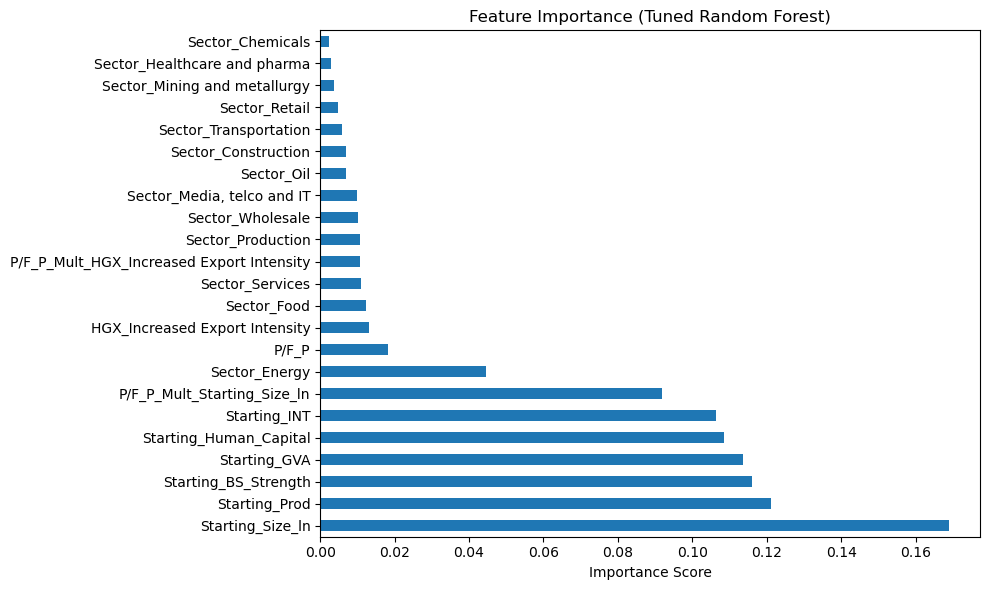

,Feature,Importance
2,Starting_Size_ln,"0,17"
5,Starting_Prod,"0,12"
1,Starting_BS_Strength,"0,12"
4,Starting_GVA,"0,11"
3,Starting_Human_Capital,"0,11"
0,Starting_INT,"0,11"
21,P/F_P_Mult_Starting_Size_ln,"0,09"
9,Sector_Energy,"0,04"
6,P/F_P,"0,02"
20,HGX_Increased Export Intensity,"0,01"


In [10]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

# 1. Drop 'const' and define input/output
X_rf = X_full.drop(columns='const')
y_rf = y

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.3, random_state=42)

# 3. Define Random Forest Model
rf = RandomForestRegressor(random_state=42)

# 4. Define Hyperparameter Grid for Random Search (updated to remove 'auto')
param_grid = {
    'n_estimators': [100, 300, 500, 700, 1000],
    'max_depth': [5, 10, 15, 20, 30, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': [1.0, 'sqrt', 'log2', 0.3, 0.5, 0.75],
    'bootstrap': [True, False]
}

# 5. Initialize RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=200,  # Increased for better tuning
    scoring='r2',  # Can also try 'neg_mean_squared_error'
    cv=10,  # Increased cross-validation for robustness
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 6. Fit the model with RandomizedSearchCV
rf_random.fit(X_train, y_train)

# 7. Extract the Best Hyperparameters & Score
best_params = rf_random.best_params_
best_score = rf_random.best_score_

print("Best Hyperparameters:", best_params)
print(f"Best R² Score from Cross-Validation: {best_score:.4f}")

# 8. Train the Final Model using Best Hyperparameters
best_rf = RandomForestRegressor(**best_params, random_state=42)
best_rf.fit(X_train, y_train)

# 9. Make Predictions on Training and Test Data
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

# 10. Evaluate the Tuned Model (Train & Test)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Print Results
print(f"\nTraining Performance:")
print(f"Train R² Score: {train_r2:.4f}")
print(f"Train Mean Squared Error: {train_mse:.4f}")

print(f"\nTest Performance:")
print(f"Test R² Score: {test_r2:.4f}")
print(f"Test Mean Squared Error: {test_mse:.4f}")

# === Debugging Check Before Step 11 ===

# Checking the number of features before model training
print(f"\nNumber of features in X_rf: {X_rf.shape[1]}")
print(f"Number of feature importances from Random Forest: {len(best_rf.feature_importances_)}")

# Make sure all columns match correctly
if X_rf.shape[1] == len(best_rf.feature_importances_):
    # 11. Feature Importance Plot
    rf_importances = pd.Series(best_rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    rf_importances.plot(kind='barh')
    plt.title("Feature Importance (Tuned Random Forest)")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()

    # 12. Display Feature Importances in DataFrame
    importance_df = pd.DataFrame({
        'Feature': X_rf.columns,
        'Importance': best_rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    display(importance_df)
else:
    print("⚠️ Feature mismatch detected! Ensure preprocessing steps are consistent.")


# OLS vs Random Forest


Metric                    OLS        Random Forest (Test)
--------------------------------------------------
R² Score                  0.1015      0.0835
MSE                       0.0853      0.0913
MAE                       0.2188      0.2295


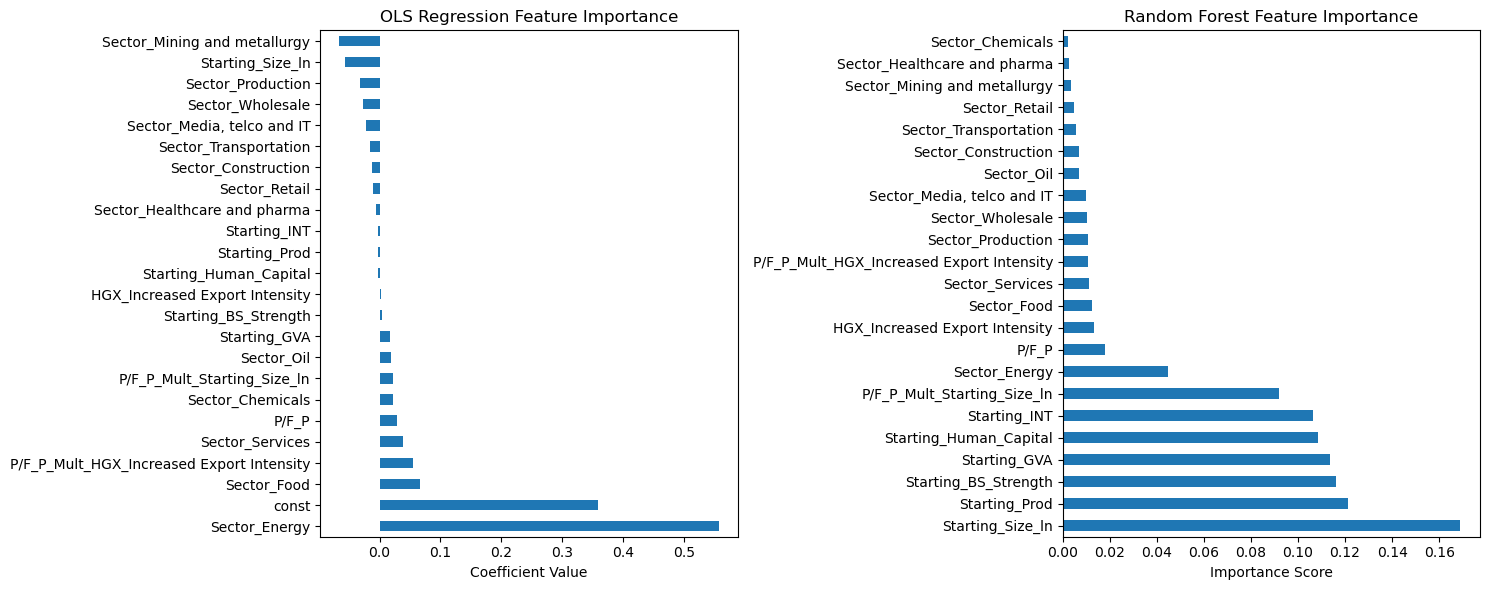

,OLS Coefficients,RF Importance
Starting_Size_ln,"-0,06","0,17"
Starting_Prod,"-0,00","0,12"
Starting_BS_Strength,"0,00","0,12"
Starting_GVA,"0,02","0,11"
Starting_Human_Capital,"-0,00","0,11"
Starting_INT,"-0,00","0,11"
P/F_P_Mult_Starting_Size_ln,"0,02","0,09"
Sector_Energy,"0,56","0,04"
P/F_P,"0,03","0,02"
HGX_Increased Export Intensity,"0,00","0,01"


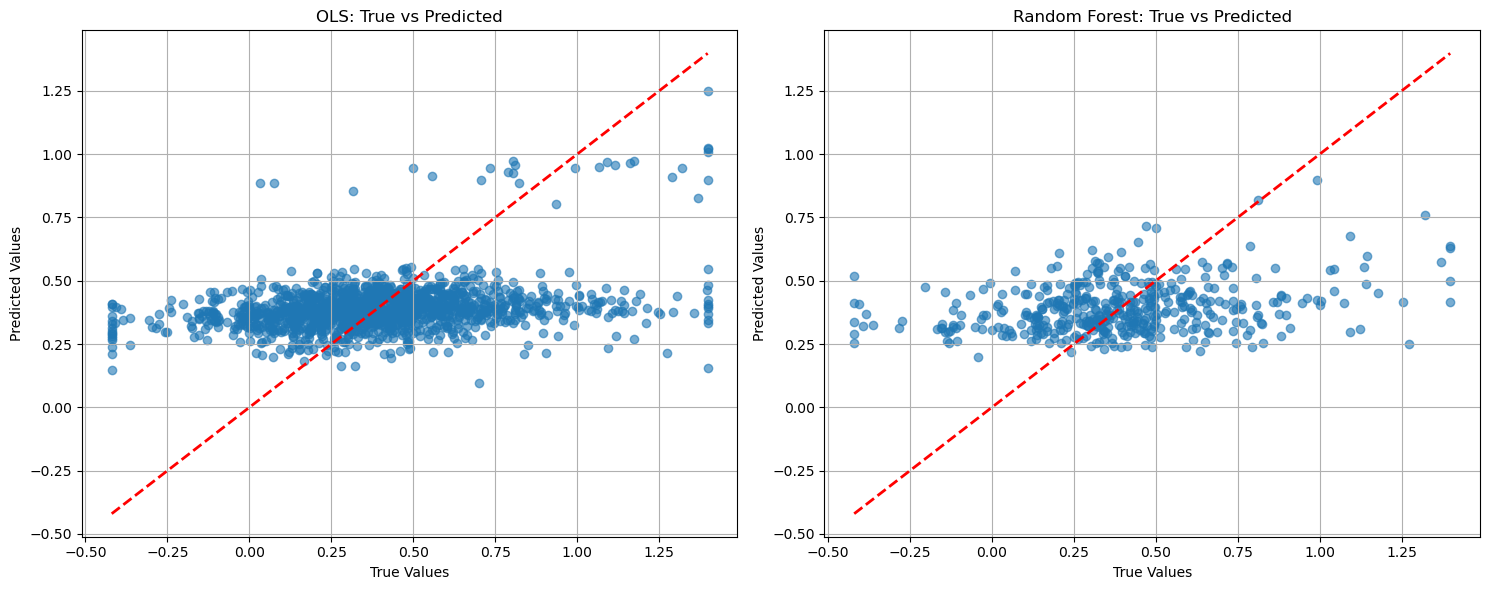

[CV] END bootstrap=True, max_depth=None, max_features=0.3, min_samples_leaf=1, min_samples_split=20, n_estimators=500; total time=   1.2s
[CV] END bootstrap=True, max_depth=15, max_features=0.3, min_samples_leaf=6, min_samples_split=10, n_estimators=500; total time=   3.9s
[CV] END bootstrap=False, max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=8, min_samples_split=20, n_estimators=700; total time=   2.0s
[CV] END bootstrap=True, max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=10, n_estimators=1000; total time=   4.5s
[CV] END bootstrap=True, max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=10, n_estimators=1000; total time=   5.5s
[CV] END bootstrap=False, max_depth=20, max_features=0.75, min_samples_leaf=4, min_samples_split=20, n_estimators=300; total time=   1.5s
[CV] END bootstrap=True, max_depth=20, max

[CV] END bootstrap=True, max_depth=15, max_features=sqrt, min_samples_leaf=4, min_samples_split=20, n_estimators=1000; total time=   1.3s
[CV] END bootstrap=False, max_depth=20, max_features=0.5, min_samples_leaf=6, min_samples_split=15, n_estimators=100; total time=   0.3s
[CV] END bootstrap=True, max_depth=15, max_features=1.0, min_samples_leaf=4, min_samples_split=15, n_estimators=1000; total time=   4.4s
[CV] END bootstrap=False, max_depth=20, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=1000; total time=   2.4s
[CV] END bootstrap=False, max_depth=15, max_features=0.3, min_samples_leaf=1, min_samples_split=20, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=15, max_features=0.3, min_samples_leaf=1, min_samples_split=20, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=15, max_features=0.3, min_samples_leaf=1, min_samples_split=20, n_estimators=100; total time=   0.3s
[CV] END bootstrap=False, max_depth=15,

[CV] END bootstrap=False, max_depth=20, max_features=0.3, min_samples_leaf=4, min_samples_split=15, n_estimators=1000; total time=   2.1s
[CV] END bootstrap=True, max_depth=None, max_features=0.3, min_samples_leaf=1, min_samples_split=20, n_estimators=500; total time=   1.1s
[CV] END bootstrap=True, max_depth=15, max_features=0.3, min_samples_leaf=6, min_samples_split=10, n_estimators=500; total time=   3.6s
[CV] END bootstrap=False, max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END bootstrap=False, max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=8, min_samples_split=20, n_estimators=700; total time=   2.0s
[CV] END bootstrap=True, max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=10, n_estimators=1000; total time=   4.6s
[CV] END bootstrap=True, max_depth=10, max

[CV] END bootstrap=False, max_depth=15, max_features=0.3, min_samples_leaf=1, min_samples_split=20, n_estimators=100; total time=   0.3s
[CV] END bootstrap=False, max_depth=15, max_features=0.3, min_samples_leaf=1, min_samples_split=20, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=None, max_features=0.3, min_samples_leaf=1, min_samples_split=20, n_estimators=500; total time=   0.9s
[CV] END bootstrap=True, max_depth=None, max_features=0.3, min_samples_leaf=1, min_samples_split=20, n_estimators=500; total time=   1.3s
[CV] END bootstrap=True, max_depth=15, max_features=0.3, min_samples_leaf=6, min_samples_split=10, n_estimators=500; total time=   3.6s
[CV] END bootstrap=False, max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=8, min_samples_split=20, n_estimators=700; total time=   2.0s
[CV] END bootstrap=True, max_depth=5, max_

[CV] END bootstrap=False, max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END bootstrap=False, max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END bootstrap=True, max_depth=5, max_features=0.5, min_samples_leaf=8, min_samples_split=20, n_estimators=700; total time=   1.9s
[CV] END bootstrap=True, max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=10, n_estimators=1000; total time=   4.6s
[CV] END bootstrap=True, max_depth=15, max_features=sqrt, min_samples_leaf=1, min_samples_split=20, n_estimators=1000; total time=   1.6s
[CV] END bootstrap=True, max_depth=15, max_features=sqrt, min_samples_leaf=1, min_samples_split=20, n_estimators=1000; total time=   2.2s
[CV] END bootstrap=True, max_depth=None, max_features=0.3, min_samples_leaf=6, min_samples_split=20, n_estimators=100; total time=   0.4s
[CV] END bootstrap=False, max_depth=5, m

In [11]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error


# === Comparison of Performance Metrics ===
ols_pred = model.predict(X_full)
ols_r2 = r2_score(y, ols_pred)
ols_mse = mean_squared_error(y, ols_pred)
ols_mae = mean_absolute_error(y, ols_pred)

rf_train_r2 = train_r2
rf_test_r2 = test_r2
rf_train_mse = train_mse
rf_test_mse = test_mse
rf_mae = mean_absolute_error(y_test, y_test_pred)

print(f"\n{'Metric':<25} {'OLS':<10} {'Random Forest (Test)':<10}")
print(f"{'-'*50}")
print(f"{'R² Score':<25} {ols_r2:.4f}      {rf_test_r2:.4f}")
print(f"{'MSE':<25} {ols_mse:.4f}      {rf_test_mse:.4f}")
print(f"{'MAE':<25} {ols_mae:.4f}      {rf_mae:.4f}")

# === Plotting Feature Importance for OLS and Random Forest ===
ols_importances = pd.Series(model.params.values, index=model.params.index).sort_values(ascending=False)
rf_importances = pd.Series(best_rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
ols_importances.plot(kind='barh')
plt.title("OLS Regression Feature Importance")
plt.xlabel("Coefficient Value")

plt.subplot(1, 2, 2)
rf_importances.plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")

plt.tight_layout()
plt.show()

# === Comparing Top 20 Features from Both Models ===
importance_comparison = pd.DataFrame({
    'OLS Coefficients': ols_importances,
    'RF Importance': rf_importances
}).sort_values(by='RF Importance', ascending=False)

display(importance_comparison.head(20))

# === Visual Comparison of Predictions ===
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.scatter(y, ols_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title('OLS: True vs Predicted')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: True vs Predicted')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.grid(True)

plt.tight_layout()
plt.show()

# SHAP Analysis

,Feature,Mean |SHAP Value|
0,Starting_Size_ln,"0,06"
1,Starting_BS_Strength,"0,03"
2,Starting_Prod,"0,02"
3,Sector_Energy,"0,02"
4,Starting_GVA,"0,02"
5,Starting_INT,"0,02"
6,Starting_Human_Capital,"0,02"
7,P/F_P_Mult_Starting_Size_ln,"0,02"
8,Sector_Food,"0,01"
9,P/F_P,"0,01"


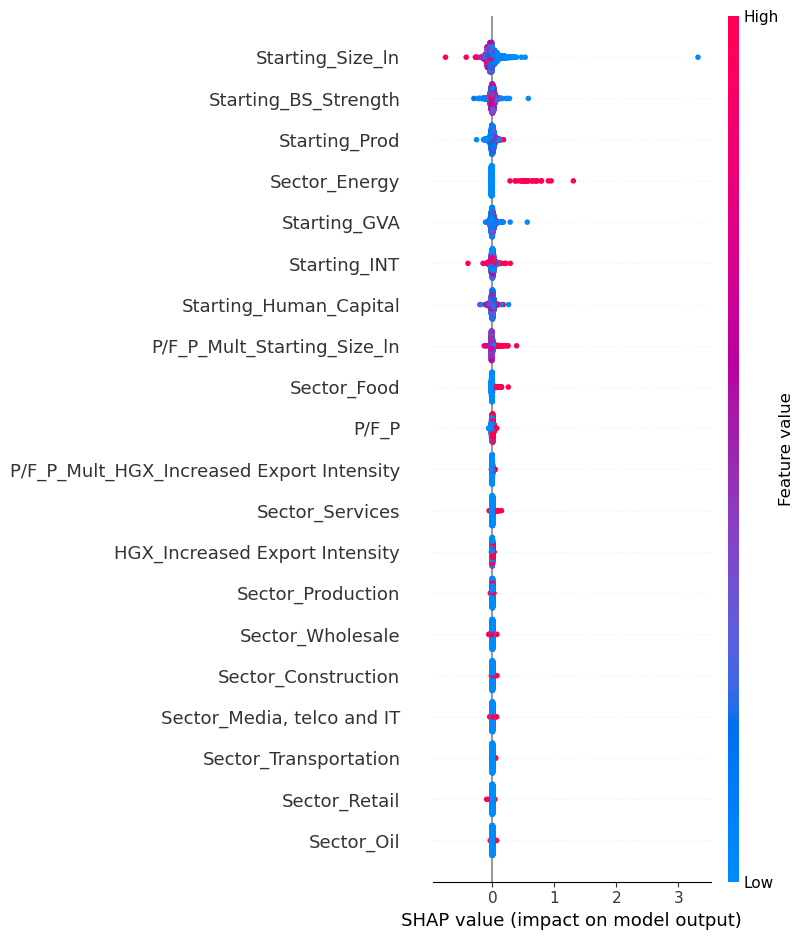

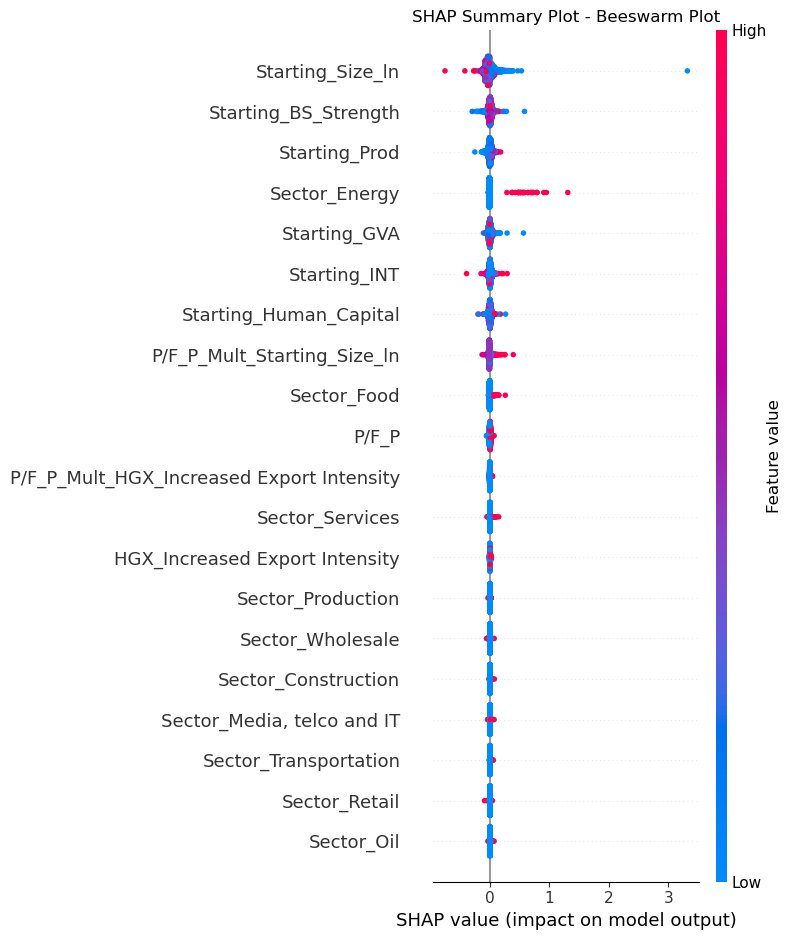

<Figure size 640x480 with 0 Axes>

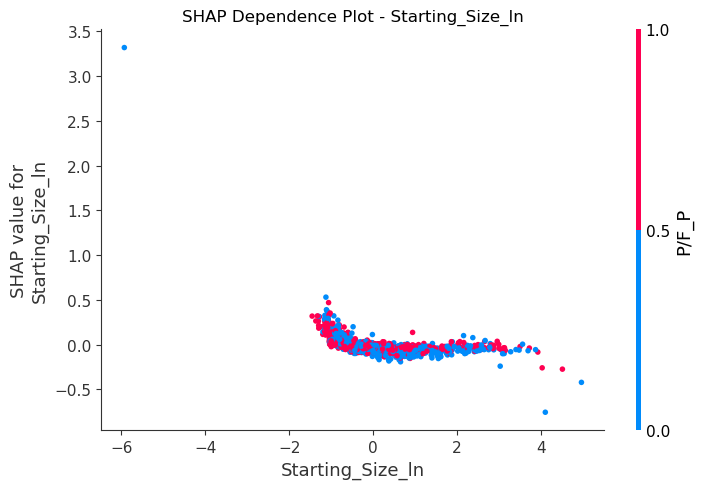

<Figure size 640x480 with 0 Axes>

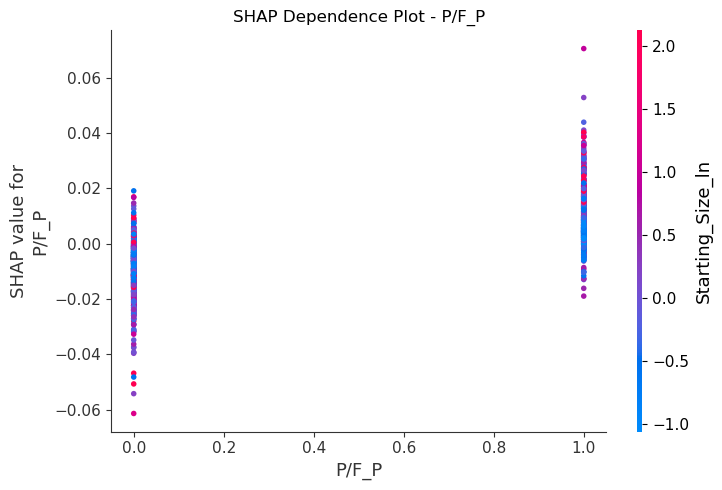

In [18]:
# Step 1: Clean feature set
X_final_cleaned = X_full.drop(columns=[col for col in all_exclusions if col in X_full.columns], errors='ignore')

# Step 2: Define target (already standardized and cleaned)
y_final = y

# Step 3: Fit Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_final_cleaned, y_final)

# Step 4: SHAP analysis
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_final_cleaned)

# Step 6: SHAP mean importance table
shap_df = pd.DataFrame(shap_values, columns=X_final_cleaned.columns)
shap_mean_importance = shap_df.abs().mean().sort_values(ascending=False)

shap_importance_df = pd.DataFrame({
    'Feature': shap_mean_importance.index,
    'Mean |SHAP Value|': shap_mean_importance.values
})

# Step 7: Show importance table
display(shap_importance_df)

# Step 5: SHAP summary plot
shap.initjs()
shap.summary_plot(shap_values, X_final_cleaned)
plt.show()

# Step 6: SHAP Summary Plot - Beeswarm Plot
plt.figure()
shap.summary_plot(shap_values, X_final_cleaned, plot_type="dot", show=False)
plt.title("SHAP Summary Plot - Beeswarm Plot")
plt.tight_layout()
plt.savefig("SHAP_Summary_Beeswarm_Plot.png", dpi=300)
plt.show()
plt.close()

# Step 9: Generate Dependence Plots for Key Features
import re

key_features = ['Starting_Size_ln', 'P/F_P']
for feature in key_features:
    plt.figure()
    shap.dependence_plot(feature, shap_values, X_final_cleaned, show=False)
    plt.title(f"SHAP Dependence Plot - {feature}")
    plt.tight_layout()
    
    # Replace special characters with an underscore
    safe_feature_name = re.sub(r'[^\w\-_\. ]', '_', feature)
    plt.savefig(f"SHAP_Dependence_{safe_feature_name}.png", dpi=300)
    plt.show()
    plt.close()

# Random Forest Feature and Permutations Importance (unrestricted)

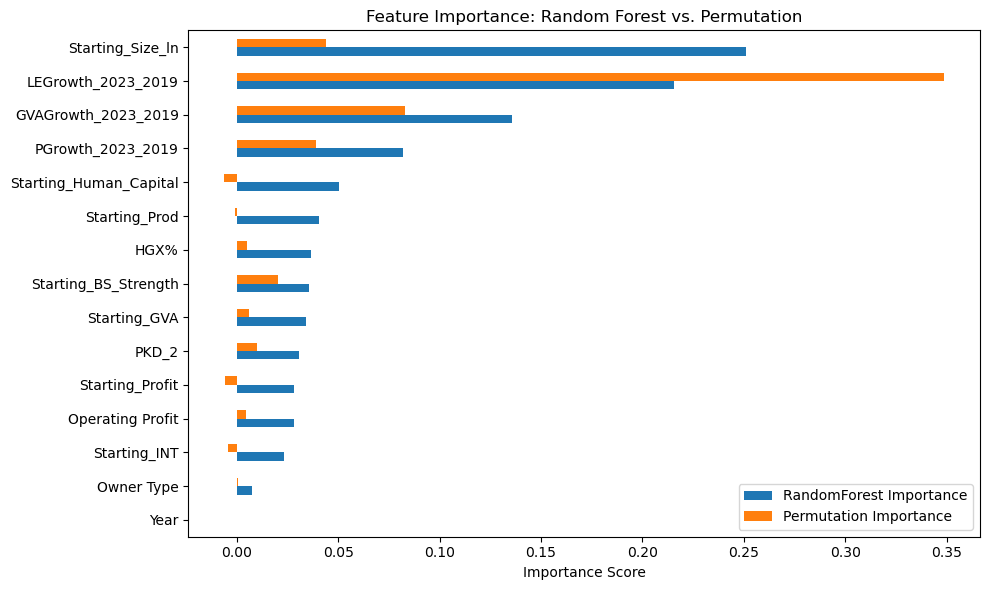

,RandomForest Importance,Permutation Importance
Starting_Size_ln,"0,25","0,04"
LEGrowth_2023_2019,"0,22","0,35"
GVAGrowth_2023_2019,"0,14","0,08"
PGrowth_2023_2019,"0,08","0,04"
Starting_Human_Capital,"0,05","-0,01"
Starting_Prod,"0,04","-0,00"
HGX%,"0,04","0,01"
Starting_BS_Strength,"0,04","0,02"
Starting_GVA,"0,03","0,01"
PKD_2,"0,03","0,01"


R^2 Score: 0.3360
Mean Squared Error: 0.0787


In [24]:
excluded_columns = ['Name', 'LRSGrowth_2023_2019',target_variable]

# Full feature set (no restriction to OLS variables)
X_rf = df_2023.drop(columns=[col for col in excluded_columns if col in df.columns])
y_rf = df_2023[target_variable]

X_rf, y_rf = X_rf.align(y_rf, join='inner', axis=0)
mask = X_rf.notna().all(axis=1)
X_rf = X_rf[mask]
y_rf = y_rf[mask]

# Encode categorical variables
X_rf = pd.get_dummies(X_rf, drop_first=True)
X_rf = X_rf.select_dtypes(include=[np.number])  # Keep only numeric data


# 1. Drop 'const' and define input/output - to restrict for OLS variables
# X_rf = X_full.drop(columns='const')
# y_rf = y

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.3, random_state=42)

# 3. Fit Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 4. Random Forest Feature Importance
rf_importances = pd.Series(rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)

# 5. Permutation Importance
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
perm_importances = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

# 6. Combine into one DataFrame
importance_df = pd.DataFrame({
    'RandomForest Importance': rf_importances,
    'Permutation Importance': perm_importances
}).sort_values(by='RandomForest Importance', ascending=True)

# 7. Plot
importance_df.plot(kind='barh', figsize=(10, 6))
plt.title("Feature Importance: Random Forest vs. Permutation")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# 8. Display numeric table
importance_df = importance_df.sort_values(by='RandomForest Importance', ascending=False)
display(importance_df)

# 9. Model Evaluation
from sklearn.metrics import r2_score, mean_squared_error

y_pred = rf.predict(X_test)

# Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R^2 Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")


In [23]:
display(df_2023.head())

,Name,Sector,Owner Type,Year,Operating Profit,PKD_2,PKD_1,Digital intensity,P/F,HGX,HGX%,LSGrowth_2023_2019,LRSGrowth_2023_2019,Drop_Sales_2020,Drop_Sales_2023,Drop_Sales_Both,GVAGrowth_2023_2019,LEGrowth_2023_2019,Drop_Employment,PGrowth_2023_2019,Starting_Profit,Starting_INT,Starting_BS_Strength,Starting_Size_ln,Starting_Human_Capital,Starting_GVA,Starting_Prod
0,"Jeronimo Martins Polska SA, Kostrzyn",Retail,500,2023,"5 121 150,49",47,G,Medium-high,F,Decreased Export Intensity,"0,00","0,57","0,25",No,No,No,"4 394 364,76","0,15",No,"42,15","0,04","0,00","0,23","17,83","53,43","6 442 185,39","94,52"
1,"PGE Polska Grupa Energetyczna GK SA, Lublin",Energy,145,2023,"-4 055 000,00",70,M,High,P,Decreased Export Intensity,"-0,00","0,94","0,61",No,No,No,"2 373 000,00","0,01",Yes,"55,60","-0,10","0,00","0,56","17,44","111,08","483 000,00","11,52"
2,"Totalizator Sportowy sp. z o.o. GK, Warszawa",Services,100,2023,"453 419,00",92,R,Medium-high,P,Decreased Export Intensity,"0,00","1,66","1,34",No,No,No,"513 096,67","1,17",No,"-160,16","0,03","0,00","0,59","16,11","188,29","658 207,33","358,89"
3,"Enea SA GK, Poznań",Energy,145,2023,"-508 049,00",35,D,Low,P,Decreased Export Intensity,"0,00","1,12","0,79",No,No,No,"360 494,00","0,05",No,"9,78","0,03","0,00","0,47","16,58","112,03","3 688 149,00","217,00"
4,"Tauron Polska Energia SA GK, Katowice",Energy,145,2023,"2 302 000,00",35,D,Low,P,Increased Export Intensity,"0,01","0,80","0,48",No,No,No,"3 482 480,00","-0,32",Yes,"223,72","-0,00","0,01","0,46","16,77","98,27","2 762 520,00","105,90"


In [26]:
display(df_clean.head())

,Name,Sector,Owner Type,Year,Operating Profit,PKD_2,PKD_1,Digital intensity,P/F,HGX,HGX%,LSGrowth_2023_2019,LRSGrowth_2023_2019,Drop_Sales_2020,Drop_Sales_2023,Drop_Sales_Both,GVAGrowth_2023_2019,LEGrowth_2023_2019,Drop_Employment,PGrowth_2023_2019,Starting_Profit,Starting_INT,Starting_BS_Strength,Starting_Size_ln,Starting_Human_Capital,Starting_GVA,Starting_Prod,LSGrowth_2023_2019_was_winsorized,LSGrowth_2023_2019_win
0,"Jeronimo Martins Polska SA, Kostrzyn",Retail,500,2023,"5 121 150,49",47,G,Medium-high,F,Decreased Export Intensity,"0,00","0,57","0,25",No,No,No,"4 394 364,76","0,15",No,"42,15","0,04","0,00","0,23","17,83","53,43","6 442 185,39","94,52",False,"0,57"
1,"PGE Polska Grupa Energetyczna GK SA, Lublin",Energy,145,2023,"-4 055 000,00",70,M,High,P,Decreased Export Intensity,"-0,00","0,94","0,61",No,No,No,"2 373 000,00","0,01",Yes,"55,60","-0,10","0,40","0,56","17,44","111,08","483 000,00","11,52",False,"0,94"
2,"Totalizator Sportowy sp. z o.o. GK, Warszawa",Services,100,2023,"453 419,00",92,R,Medium-high,P,Decreased Export Intensity,"0,00","1,66","1,34",No,No,No,"513 096,67","1,17",No,"-160,16","0,03","0,00","0,59","16,11","188,29","658 207,33","358,89",True,"0,95"
3,"Enea SA GK, Poznań",Energy,145,2023,"-508 049,00",35,D,Low,P,Decreased Export Intensity,"0,00","1,12","0,79",No,No,No,"360 494,00","0,05",No,"9,78","0,03","0,00","0,47","16,58","112,03","3 688 149,00","217,00",True,"0,95"
4,"Tauron Polska Energia SA GK, Katowice",Energy,145,2023,"2 302 000,00",35,D,Low,P,Increased Export Intensity,"0,01","0,80","0,48",No,No,No,"3 482 480,00","-0,32",Yes,"223,72","-0,00","1,07","0,46","16,77","98,27","2 762 520,00","105,90",False,"0,80"
